# This data was generated by calling the API
Every request was the same summary (same content score)
A random score history was provided

In [1]:
import random
from pathlib import Path
from collections import defaultdict
import itertools as it
import os

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from conjugate_normal import conjugate_normal

In [20]:
df1 = pd.read_json("fake_summary_scores.jsonl", lines=True)
df2 = pd.json_normalize(df1["metrics"], sep="_")
df = pd.concat([
    df1,
    df2,
], axis=1)
df = df.dropna(subset=["content_score"])
df

,detail,score_history,is_passed,prompt,metrics,containment_name,containment_is_passed,containment_score,containment_threshold,containment_feedback,...,english_name,english_is_passed,english_score,english_threshold,english_feedback,profanity_name,profanity_is_passed,profanity_score,profanity_threshold,profanity_feedback
2,NaN,[0.287840999431621],0.0,"Before moving onto the next page, you will nee...","{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,
3,NaN,"[0.26600713037454304, 0.48489234650454105]",0.0,"Before moving onto the next page, you will nee...","{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,
4,NaN,[0.41645840152072605],0.0,"Before moving onto the next page, you will nee...","{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,
5,NaN,[0.092413747001498],0.0,"Before moving onto the next page, you will nee...","{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,
7,NaN,"[0.20988929959666902, 0.436860791846278, 0.119...",0.0,"Before moving onto the next page, you will nee...","{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,
9,NaN,"[0.45951983633574606, 0.46674678067510206, 0.3...",0.0,"Before moving onto the next page, you will nee...","{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,
11,NaN,[0.074220762119032],1.0,Excellent job summarizing the text. Please mov...,"{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,
12,NaN,"[0.328457606073003, 0.33590973200822005]",1.0,Excellent job summarizing the text. Please mov...,"{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,
13,NaN,[0.395712357749229],1.0,Excellent job summarizing the text. Please mov...,"{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,
14,NaN,"[0.597765120950005, 0.35623036779931]",0.0,"Before moving onto the next page, you will nee...","{'containment': {'name': 'Language Borrowing',...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,


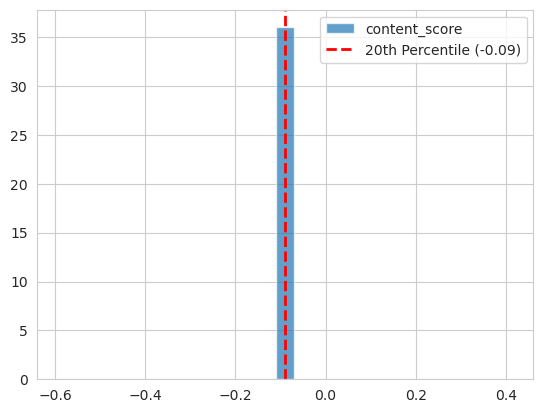

In [21]:
df["content_score"].hist(legend=True, bins=25, alpha=0.7);

# Calculate and add the 20th percentile line
percentile_20 = df["content_score"].quantile(0.2)
plt.axvline(percentile_20, color='red', linestyle='--', linewidth=2, label=f"20th Percentile ({percentile_20:.2f})")

# Add legend and show
plt.legend()
plt.show()

In [22]:
mu_global = 0.8
k_global = 15
alpha_global = 4
beta_global = 1

k_volume = 3

In [23]:
volumes = {}
volume_updates = []
submission_threshold = []

volume = conjugate_normal(mu_global, k_global, alpha_global, beta_global, percentile=0.2)
start_threshold = volume.threshold

student_score_history = defaultdict(list)

for i, row in enumerate(df.itertuples()):
    # Create temporary volume prior from volume prior information
    student_dist = conjugate_normal(volume.mu, k_volume, volume.alpha, volume.beta, percentile=0.2)

    # Update temporary volume prior with score history
    score_history = row.score_history
    if score_history:
        student_dist.update(score_history)

    # Record threshold
    submission_threshold.append(student_dist.threshold)

    volume.update([row.content_score], increment_k=True)

    volume_updates.append((volume.mu, volume.sigma, volume.threshold))
    
df["bayesian_threshold"] = submission_threshold

In [24]:
df["content_score"]
df["bayesian_threshold"]

2     0.193658
3     0.118687
4     0.092512
5    -0.042841
7    -0.067881
9    -0.009481
11   -0.137554
12   -0.089220
13   -0.091783
14   -0.060080
15   -0.124437
16   -0.148986
17   -0.177710
20   -0.164113
22   -0.242839
23   -0.162301
24   -0.150034
25   -0.190602
26   -0.194646
28   -0.189083
30   -0.171973
31   -0.237410
33   -0.276531
34   -0.197636
35   -0.175118
37   -0.201997
38   -0.146110
39   -0.172508
41   -0.207785
42   -0.233844
43   -0.225004
44   -0.144191
45   -0.187989
46   -0.240489
47   -0.226250
49   -0.220702
Name: bayesian_threshold, dtype: float64

In [25]:
df.index

Index([ 2,  3,  4,  5,  7,  9, 11, 12, 13, 14, 15, 16, 17, 20, 22, 23, 24, 25,
       26, 28, 30, 31, 33, 34, 35, 37, 38, 39, 41, 42, 43, 44, 45, 46, 47, 49],
      dtype='int64')

,Observed,Simulated Bayesian Personalized,Simulated Bayesian Volume Prior Only,20th Percentile
0,0.81,0.81,0.72,0.0


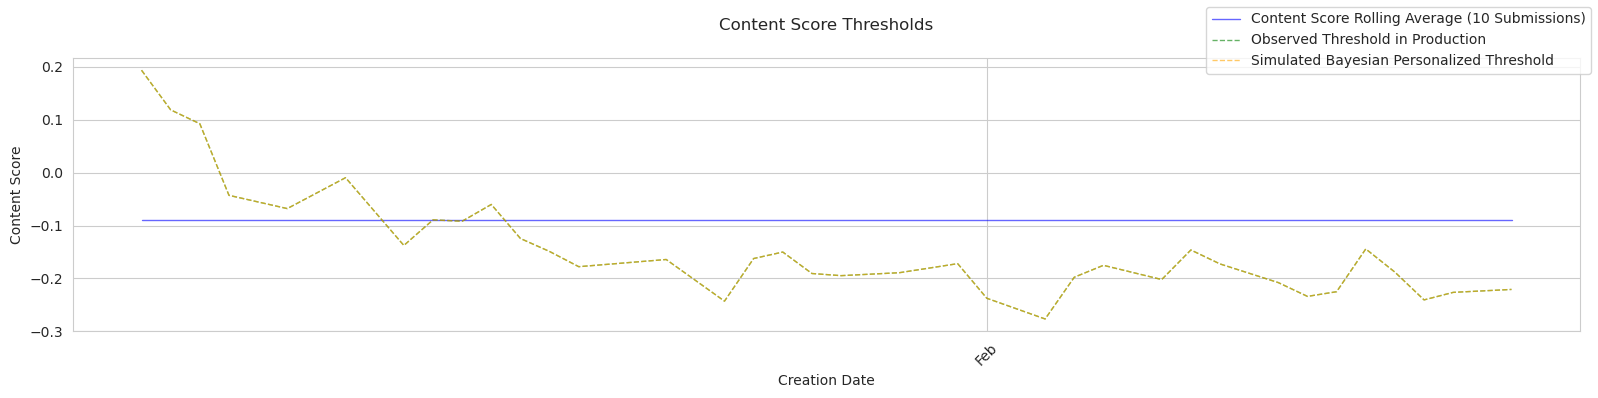

In [29]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, figsize=(16, 4))

pass_rates = []

# Calculate and plot rolling average (10 submissions)
rolling_avg = df['content_score'].rolling(window=10, min_periods=1).mean()
sns.lineplot(ax=ax, x=df.index, y=rolling_avg, 
             label='Content Score Rolling Average (10 Submissions)', legend=False,
             color='blue', linewidth=1, alpha=0.6)

# Draw Observed Threshold (as the student experienced it)
sns.lineplot(ax=ax, data=df, x=df.index, y='content_threshold', 
             label='Observed Threshold in Production', legend=False,
             color='green', linewidth=1, alpha=0.6, linestyle='dashed')

# Draw Volume Prior
# updates_array = np.array(volume_updates)
# sns.lineplot(ax=ax, x=df.index, y=updates_array[:,2], 
#              label='Simulated Bayesian Volume Prior Threshold', legend=False,
#              color='purple', linewidth=1, alpha=0.6, linestyle='dashed')

# Draw Bayesian Threshold
sns.lineplot(ax=ax, data=df, x=df.index, y='bayesian_threshold', 
             label='Simulated Bayesian Personalized Threshold', legend=False,
             color='orange', linewidth=1, alpha=0.6, linestyle='dashed')

# Manually set the threshold for the first window_size samples
# Since we don't have enough data to calculate a fair rolling averagewindow_size = 10
window_size=10
rolling_20th = df["content_score"].rolling(window=window_size, min_periods=1, closed='left').quantile(0.2)
rolling_20th.iloc[:window_size] = 0.0

# Print Pass Rates
pass_rates.append({
    "Observed": (df["content_score"] > df["content_threshold"]).astype(int).mean(),
    "Simulated Bayesian Personalized": (df["content_score"] > df["bayesian_threshold"]).astype(int).mean(),
    "Simulated Bayesian Volume Prior Only": (df["content_score"] > updates_array[:,2]).astype(int).mean(),
    "20th Percentile": (df["content_score"] > rolling_20th).astype(int).mean(),
})

# Format x-axis to show only month-year
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mpl.dates.MonthLocator(interval=3))

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show Pass Rates
display(pd.DataFrame(pass_rates).round(2))

# Add legend
labels_handles = {}
for ax in fig.axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        labels_handles[label] = handle

fig.legend(labels_handles.values(), labels_handles.keys(), loc='upper right', bbox_transform=fig.transFigure, ncol=1)

plt.title('Content Score Thresholds', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')
plt.tight_layout()
    
plt.show();